# import libraries

Explanation
* yfinance retrieves stock data.
* Pandas handles data manipulation.
* Scikit-learn builds the prediction model.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Historical Stock Data

Apple stock data is downloaded directly from Yahoo Finance.

In [26]:
df = yf.download("AAPL")

# Convert MultiIndex columns to normal columns
df.columns = df.columns.get_level_values(0)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-05-26,308.329987,311.820007,307.670013,309.559998,48000500
2026-05-27,310.850006,313.260010,308.299988,308.329987,50430900
2026-05-28,312.510010,312.799988,309.570007,310.679993,48220400
2026-05-29,312.059998,315.000000,309.529999,311.779999,70026800
2026-06-01,306.309998,310.940002,305.019989,309.630005,48849900


# Data Preprocessing
 Create Target Variable

 --The closing price of the next day becomes the target variable

In [28]:
df['Next_Close'] = df['Close'].shift(-1)

df.dropna(inplace=True)

# Select Features and Target

Explanation

Input Features:

* Open
* High
* Low
* Volume

Target:

* Next Day Close Price

In [29]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Next_Close']

# Split Data

80% of data is used for training and 20% for testing.

In [17]:
split_index = int(len(df) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Train Linear Regression Model

Linear Regression learns relationships between stock features and future closing price.

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Make Prediction

In [19]:
y_pred = model.predict(X_test)

# Evaluate Model

* MAE measures average prediction error.
* MSE penalizes larger errors.
* R² indicates model accuracy.

In [31]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 30.235531608126813
Mean Squared Error: 1096.5578692043123
R-squared: -4.631321997131396


# plot Actual Vs Predicated Prices

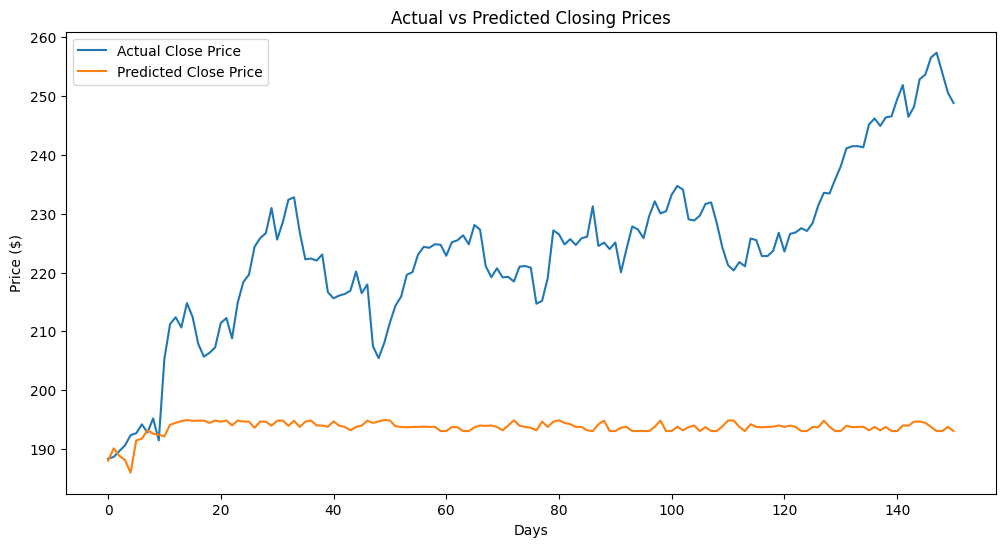

In [32]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Close Price'
)

plt.plot(
    y_pred,
    label='Predicted Close Price'
)

plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.legend()

plt.show()

# Predict Tomorrow's Price

In [33]:
latest_data = X.iloc[-1:]

tomorrow_price = model.predict(latest_data)

print("Predicted Next Day Closing Price:")
print(tomorrow_price[0])

Predicted Next Day Closing Price:
194.83293045043945


c:\Users\talha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


# Random Forest Regression

In [34]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)